# Filter Benchmark + EfficientNetV2-XL (Geometry-Aware)

This notebook is based on the filter benchmark pipeline, but uses the main choices that usually improve performance in the EfficientNet notebook:
- input resolution 512x512
- EfficientNetV2-XL pretrained on ImageNet
- Focal Loss for class imbalance
- stronger augmentation
- geometry-aware preprocessing (pad-to-square before resize for rectangular images, including type V).

In [45]:
import os
import json
import copy
import random
import warnings
from typing import Callable

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
import timm

from monai.losses import FocalLoss
from monai.utils import set_determinism

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

DATA_ROOT = '/mounts/mecd-ap-g5/data'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'
NOTEBOOK_NAME = 'filter_benchmark_efficientnet_v2_xl'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

SEED = 42
IMG_SIZE = 512
# Default batch size tuned for RTX 6000 Ada (48GB). Reduce if you hit OOM.
BATCH_SIZE = 4
NUM_WORKERS = 4
NUM_EPOCHS = 40
PATIENCE = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True
GEOMETRY_MODE = 'pad_resize_if_rect'  # options: direct_resize, pad_resize_if_rect
USE_CLAHE = False
# Gradient accumulation and mixed precision settings to help train XL on limited GPUs
GRADIENT_ACCUMULATION_STEPS = 2
MIXED_PRECISION = True  # use AMP when CUDA available
# Optional: path to resume from an existing checkpoint (set to None to disable)
RESUME_FROM = None

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

set_determinism(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', torch.cuda.get_device_properties(0).total_memory / 1e9)
print('RESULTS_DIR:', RESULTS_DIR)
print('MODELS_DIR:', MODELS_DIR)


Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM (GB): 50.86216192
RESULTS_DIR: /mounts/mecd-ap-g5/results/filter_benchmark_efficientnet_v2_xl
MODELS_DIR: /mounts/mecd-ap-g5/models/filter_benchmark_efficientnet_v2_xl


In [46]:
METADATA_PATH = os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'metadata.csv')
df = pd.read_csv(METADATA_PATH)

EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}
FUSED_LABEL_MAP = {
    'Benign Stricture': 'Stricture',
    'Malignant Stricture': 'Stricture',
    'Biliary Leaks': 'Biliary Leaks',
    'Lithiasis': 'Lithiasis',
    'Normal': 'Normal',
}
FINAL_CLASSES = ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']

filtered = df[(df['Keep'].astype(str).str.strip().str.lower() == 'keep') & (~df['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS))].copy()
filtered['Label'] = filtered['Label'].astype(str).str.strip()
filtered['final_label'] = filtered['Label'].map(FUSED_LABEL_MAP)
filtered = filtered[filtered['final_label'].isin(FINAL_CLASSES)].copy()
filtered['image_path'] = filtered['processed_image_path'].apply(lambda p: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', p))
filtered = filtered[filtered['image_path'].apply(os.path.exists)].copy().reset_index(drop=True)

class_names = list(FINAL_CLASSES)
class_to_idx = {label_name: idx for idx, label_name in enumerate(class_names)}
filtered['target'] = filtered['final_label'].map(class_to_idx)

print('Total filtered samples:', len(filtered))
print('Class distribution:')
print(filtered['final_label'].value_counts())
print('Image type distribution:')
print(filtered['image_type'].value_counts())

Total filtered samples: 1568
Class distribution:
final_label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64
Image type distribution:
image_type
S    1521
V      47
Name: count, dtype: int64


In [47]:
patient_summary = filtered.groupby('patient_id').agg(patient_label=('final_label', lambda x: x.mode().iloc[0])).reset_index()
train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_summary['patient_label']
)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients['patient_label']
)

train_df = filtered[filtered['patient_id'].isin(train_patients['patient_id'])].copy().reset_index(drop=True)
val_df = filtered[filtered['patient_id'].isin(val_patients['patient_id'])].copy().reset_index(drop=True)
test_df = filtered[filtered['patient_id'].isin(test_patients['patient_id'])].copy().reset_index(drop=True)

print('Split sizes:')
print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{split_name} label distribution:')
    print(split_df['final_label'].value_counts())
    print(f'{split_name} image_type distribution:')
    print(split_df['image_type'].value_counts())

Split sizes:
train: 1001 val: 313 test: 254

train label distribution:
final_label
Lithiasis        468
Stricture        249
Normal           206
Biliary Leaks     78
Name: count, dtype: int64
train image_type distribution:
image_type
S    967
V     34
Name: count, dtype: int64

val label distribution:
final_label
Lithiasis        142
Stricture         58
Normal            58
Biliary Leaks     55
Name: count, dtype: int64
val image_type distribution:
image_type
S    304
V      9
Name: count, dtype: int64

test label distribution:
final_label
Lithiasis        116
Stricture         85
Normal            35
Biliary Leaks     18
Name: count, dtype: int64
test image_type distribution:
image_type
S    250
V      4
Name: count, dtype: int64


In [48]:
def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:
    w, h = image.size
    if w == h:
        return image
    side = max(w, h)
    canvas = Image.new(image.mode, (side, side), fill)
    canvas.paste(image, ((side - w) // 2, (side - h) // 2))
    return canvas

def apply_clahe_rgb(image: Image.Image, clip_limit=2.0, tile_grid_size=(8, 8)) -> Image.Image:
    rgb = np.array(image.convert('RGB'))
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel = clahe.apply(l_channel)
    merged = cv2.merge((l_channel, a_channel, b_channel))
    out = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)

def preprocess_image(image: Image.Image, geometry_mode='pad_resize_if_rect', use_clahe=False) -> Image.Image:
    image = image.convert('RGB')
    if use_clahe:
        image = apply_clahe_rgb(image)
    if geometry_mode == 'pad_resize_if_rect':
        image = pad_to_square(image)
    elif geometry_mode == 'direct_resize':
        pass
    else:
        raise ValueError(f'Unknown geometry_mode: {geometry_mode}')
    image = image.resize((IMG_SIZE, IMG_SIZE))
    return image

In [49]:
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ERCPDataset(train_df, train_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
val_ds = ERCPDataset(val_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
test_ds = ERCPDataset(test_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)

class_counts = train_df['target'].value_counts().sort_index()
class_weights = torch.tensor(len(train_df) / (len(class_counts) * class_counts.values), dtype=torch.float32)
weight_lookup = {i: float(w) for i, w in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Class weights:', class_weights)

Class weights: tensor([3.2083, 0.5347, 1.2148, 1.0050])


In [50]:
def build_efficientnet_v2_xl(num_classes, pretrained=True):
    """Create EfficientNetV2-XL. If pretrained weights are unavailable, fall back to random init with a clear message."""
    try:
        model = timm.create_model('efficientnetv2_xl', pretrained=pretrained, num_classes=num_classes)
        print(f"Created efficientnetv2_xl (pretrained={pretrained})")
        return model
    except RuntimeError as e:
        msg = str(e)
        if 'No pretrained weights' in msg or 'No pretrained' in msg:
            print('Warning: No pretrained ImageNet weights available for efficientnetv2_xl. Proceeding with random init (pretrained=False).')
            model = timm.create_model('efficientnetv2_xl', pretrained=False, num_classes=num_classes)
            return model
        raise


def compute_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except Exception:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except Exception:
        metrics['pr_auc_macro'] = np.nan
    return metrics


In [51]:
def evaluate(model, loader, criterion):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.array(all_probs)
    metrics = compute_metrics(all_targets, all_preds, all_probs, class_names)
    metrics['loss'] = avg_loss
    return metrics, np.array(all_targets), np.array(all_preds), all_probs


def train_model():
    model = build_efficientnet_v2_xl(len(class_names), pretrained=USE_PRETRAINED).to(device)
    criterion = FocalLoss(to_onehot_y=True)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(MIXED_PRECISION and torch.cuda.is_available()))

    # Optional resume from checkpoint
    if RESUME_FROM is not None and os.path.exists(RESUME_FROM):
        try:
            state = torch.load(RESUME_FROM, map_location=device)
            model.load_state_dict(state)
            print(f"Resumed model weights from {RESUME_FROM}")
        except Exception as e:
            print(f"Failed to load resume checkpoint: {e}")

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        all_targets, all_preds = [], []

        optimizer.zero_grad()
        for step, (images, targets) in enumerate(train_loader):
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(MIXED_PRECISION and torch.cuda.is_available())):
                outputs = model(images)
                loss = criterion(outputs, targets)
                loss = loss / float(GRADIENT_ACCUMULATION_STEPS)

            scaler.scale(loss).backward()

            if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            # account for division earlier to aggregate loss per-sample
            running_loss += (loss.item() * float(GRADIENT_ACCUMULATION_STEPS)) * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
        val_f1 = val_metrics['macro_f1']

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_macro_f1': train_f1,
            'val_loss': val_metrics['loss'],
            'val_macro_f1': val_f1,
            'val_accuracy': val_metrics['accuracy'],
            'val_auc': val_metrics.get('roc_auc_ovo_macro', np.nan),
        })

        scheduler.step()

        print(f"Epoch {epoch + 1:02d} | train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} | val_f1 {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(MODELS_DIR, 'best_efficientnet_v2_xl_geometry.pth'))
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print('Early stopping triggered')
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_xl_geometry.csv'), index=False)
    return model, history_df, best_epoch, best_val_f1


Using analysis device: cpu
Best epoch: 3
Best val macro F1: 0.5658991391107464


,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_accuracy,val_auc
8,9,0.012050,0.981532,0.245351,0.487537,0.587859,0.822842
9,10,0.010278,0.983337,0.209979,0.563839,0.661342,0.859243
10,11,0.007292,0.987894,0.289261,0.472672,0.600639,0.801373
11,12,0.005976,0.987128,0.254422,0.472788,0.584665,0.786297
12,13,0.003905,0.996020,0.310007,0.477781,0.581470,0.781023


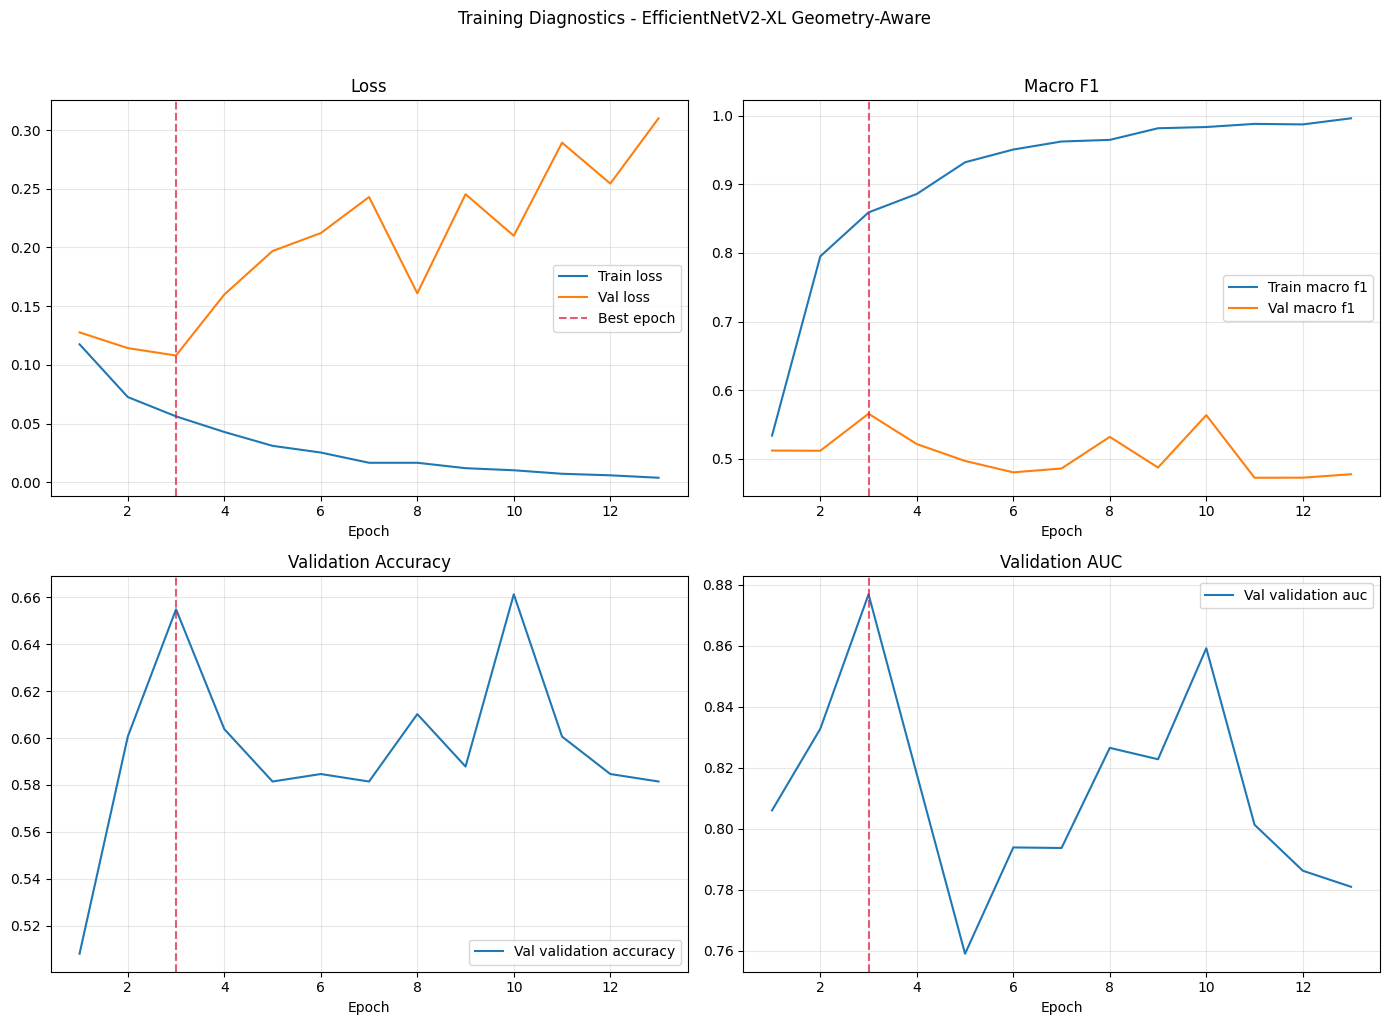

In [52]:
device = torch.device('cpu')
print('Using analysis device:', device)
history_path = os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_xl_geometry.csv')
checkpoint_path = os.path.join(MODELS_DIR, 'best_efficientnet_v2_xl_geometry.pth')

if os.path.exists(history_path):
    history_df = pd.read_csv(history_path)
else:
    history_df = None
    print(f'No XL training history found at {history_path}.')
    print('If you have not trained EfficientNetV2-XL yet, the training diagnostics section will be skipped.')

if history_df is not None and not history_df.empty:
    history_df = history_df.sort_values('epoch').reset_index(drop=True)
    history_df.to_csv(history_path, index=False)
    best_epoch = int(history_df.loc[history_df['val_macro_f1'].idxmax(), 'epoch'])
    best_val_f1 = float(history_df['val_macro_f1'].max())
    print('Best epoch:', best_epoch)
    print('Best val macro F1:', best_val_f1)
    display(history_df.tail())

    plot_cols = [
        ('train_loss', 'val_loss', 'Loss'),
        ('train_macro_f1', 'val_macro_f1', 'Macro F1'),
        (None, 'val_accuracy', 'Validation Accuracy'),
        (None, 'val_auc', 'Validation AUC'),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    for ax, (train_col, val_col, title) in zip(axes, plot_cols):
        if train_col is not None and train_col in history_df.columns:
            ax.plot(history_df['epoch'], history_df[train_col], label=f'Train {title.lower()}')
        if val_col in history_df.columns:
            ax.plot(history_df['epoch'], history_df[val_col], label=f'Val {title.lower()}')
        ax.axvline(best_epoch, color='crimson', linestyle='--', alpha=0.7, label='Best epoch' if ax is axes[0] else None)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(alpha=0.3)
        ax.legend()
    fig.suptitle('Training Diagnostics - EfficientNetV2-XL Geometry-Aware', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'training_diagnostics_efficientnet_v2_xl_geometry.png'), dpi=200, bbox_inches='tight')
    plt.show()

    summary_rows = [{
        'best_epoch': best_epoch,
        'best_val_macro_f1': best_val_f1,
        'final_val_loss': float(history_df['val_loss'].iloc[-1]) if 'val_loss' in history_df.columns else np.nan,
        'final_val_accuracy': float(history_df['val_accuracy'].iloc[-1]) if 'val_accuracy' in history_df.columns else np.nan,
        'final_val_auc': float(history_df['val_auc'].iloc[-1]) if 'val_auc' in history_df.columns else np.nan,
    }]
    pd.DataFrame(summary_rows).to_csv(os.path.join(RESULTS_DIR, 'training_summary_efficientnet_v2_xl_geometry.csv'), index=False)
else:
    best_epoch = None
    best_val_f1 = None
    print('Skipping training diagnostics because no XL history file exists.')

Using analysis device: cpu
No XL checkpoint found at /mounts/mecd-ap-g5/models/filter_benchmark_efficientnet_v2_xl/best_efficientnet_v2_xl_geometry.pth; using pretrained ImageNet weights as a fallback baseline.
Test metrics:
accuracy: 0.4488
balanced_accuracy: 0.2507
macro_f1: 0.1677
macro_precision: 0.1461
macro_recall: 0.2507
roc_auc_ovo_macro: 0.5009
pr_auc_macro: 0.2506
loss: 644465899075567.8750


,model,geometry_mode,use_clahe,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_roc_auc_ovo_macro,test_pr_auc_macro,test_loss
0,efficientnet_v2_xl,pad_resize_if_rect,False,0.448819,0.250677,0.167705,0.146087,0.250677,0.500872,0.250556,6.444659e+14


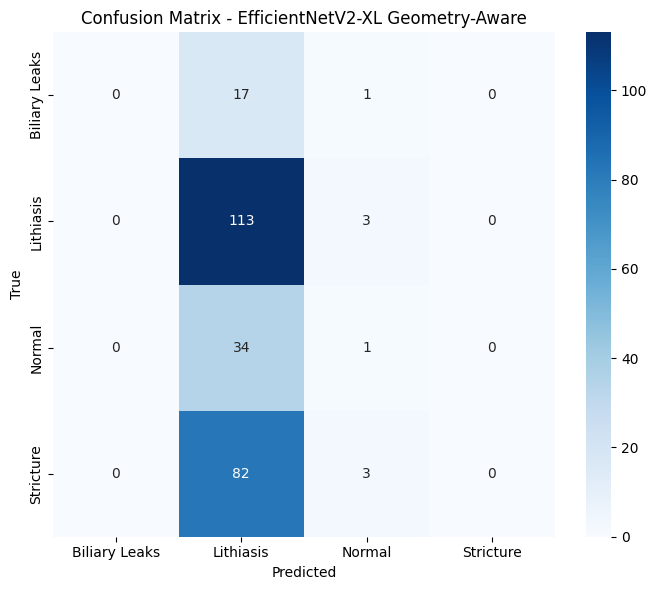

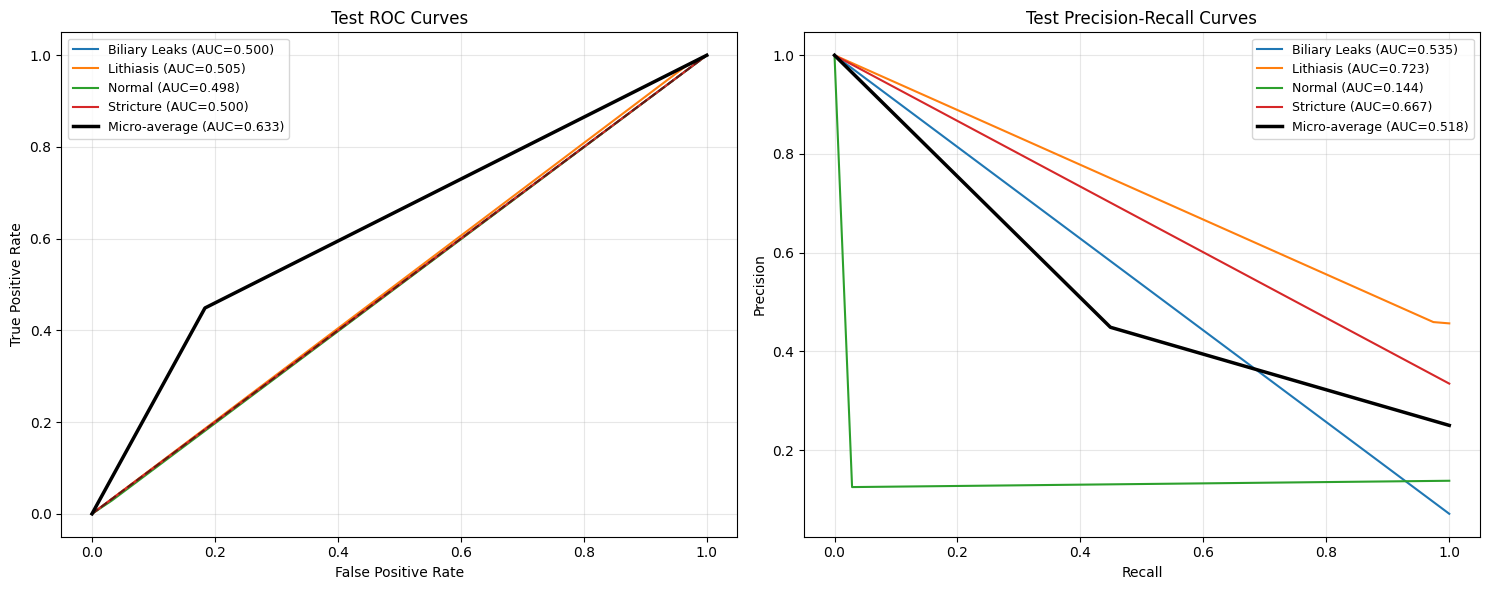

In [53]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

device = torch.device('cpu')
print('Using analysis device:', device)
checkpoint_path = os.path.join(MODELS_DIR, 'best_efficientnet_v2_xl_geometry.pth')
if os.path.exists(checkpoint_path):
    model = build_efficientnet_v2_xl(len(class_names), pretrained=False)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f'Loaded fine-tuned XL checkpoint from {checkpoint_path}')
else:
    model = build_efficientnet_v2_xl(len(class_names), pretrained=True)
    print(f'No XL checkpoint found at {checkpoint_path}; using pretrained ImageNet weights as a fallback baseline.')
model = model.to(device)
model.eval()

criterion = FocalLoss(to_onehot_y=True)
test_metrics = globals().get('test_metrics')
y_true = globals().get('y_true')
y_pred = globals().get('y_pred')
y_prob = globals().get('y_prob')
if test_metrics is None or y_true is None or y_prob is None:
    analysis_test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
    test_metrics, y_true, y_pred, y_prob = evaluate(model, analysis_test_loader, criterion)

print('Test metrics:')
for k, v in test_metrics.items():
    print(f'{k}: {v:.4f}' if isinstance(v, (float, np.floating)) else f'{k}: {v}')

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

with open(os.path.join(RESULTS_DIR, 'classification_report_efficientnet_v2_xl_geometry.json'), 'w') as f:
    json.dump(report, f, indent=2)

pd.DataFrame(report).transpose().to_csv(os.path.join(RESULTS_DIR, 'classification_report_efficientnet_v2_xl_geometry.csv'))
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(RESULTS_DIR, 'confusion_matrix_efficientnet_v2_xl_geometry.csv'))

summary = pd.DataFrame([{
    'model': 'efficientnet_v2_xl',
    'geometry_mode': GEOMETRY_MODE,
    'use_clahe': USE_CLAHE,
    **{f'test_{k}': v for k, v in test_metrics.items()}
}])
summary.to_csv(os.path.join(RESULTS_DIR, 'test_summary_efficientnet_v2_xl_geometry.csv'), index=False)
display(summary)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNetV2-XL Geometry-Aware')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_efficientnet_v2_xl_geometry.png'), dpi=200, bbox_inches='tight')
plt.show()

y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, idx], y_prob[:, idx])
    roc_auc_value = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc_value:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].plot(fpr_micro, tpr_micro, label=f'Micro-average (AUC={roc_auc_micro:.3f})', linewidth=2.5, color='black')
axes[0].set_title('Test ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)
for idx, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, idx], y_prob[:, idx])
    pr_auc_value = auc(recall, precision)
    axes[1].plot(recall, precision, label=f'{class_name} (AUC={pr_auc_value:.3f})')
axes[1].plot(recall_micro, precision_micro, label=f'Micro-average (AUC={pr_auc_micro:.3f})', linewidth=2.5, color='black')
axes[1].set_title('Test Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_pr_curves_efficientnet_v2_xl_geometry.png'), dpi=200, bbox_inches='tight')
plt.show()

## Notes
- This notebook is intentionally aligned with the stronger EfficientNet setup.
- If you want direct comparability against `filter_benchmark_clahe`, keep the same patient split seed and report macro F1/AUC side by side.
- To run an ablation, switch `GEOMETRY_MODE` to `direct_resize` and rerun.